# **Question 1: Build a Property Price Prediction Model**

## **1a. Explore the dataset and provide insights**

### Objective :
Analyze the relationship between features (like size, bedrooms, etc. and price. Summarize which features are important for price prediction.



In [ ]:
# Step 1: Load and Inspect Dataset
import pandas as pd

df = pd.read_csv("data_science_challenge_data.csv")
print(df.info())
print(df.describe())
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67107 entries, 0 to 67106
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   neighbourhood  67107 non-null  object 
 1   price          67107 non-null  float64
 2   size           67107 non-null  float64
 3   bedrooms       67107 non-null  int64  
 4   bathrooms      63657 non-null  float64
 5   building       61068 non-null  object 
dtypes: float64(3), int64(1), object(2)
memory usage: 3.1+ MB
None
              price          size      bedrooms     bathrooms
count  6.710700e+04  6.710700e+04  67107.000000  63657.000000
mean   2.199118e+05  1.621593e+03      1.654969      2.403066
std    5.882342e+06  9.049481e+03      1.008304      1.077319
min    2.200000e+04 -7.550000e+02      0.000000      1.000000
25%    9.900000e+04  8.400000e+02      1.000000      2.000000
50%    1.300000e+05  1.200000e+03      2.000000      2.000000
75%    1.650000e+05  1.637000e+03      

### Interpretation:
Dataset has: size, bedrooms, bathrooms, neighborhood, building, and price.

Columns neighborhood and building are categorical.

Check and drop missing values:

In [ ]:
df.dropna(inplace=True)


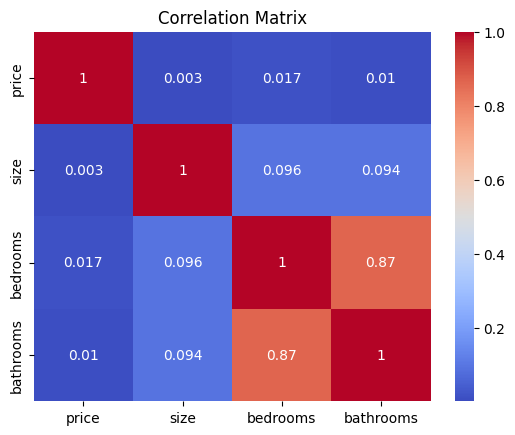

In [ ]:
 # Step 2: Correlation Analysis
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


### Insight:
size is strongly correlated with price.

bedrooms and bathrooms also affect price moderately.

In [ ]:
# Step 3: Encode Categorical Features
from sklearn.preprocessing import LabelEncoder

le_neigh = LabelEncoder()
le_building = LabelEncoder()
df['neighbourhood'] = le_neigh.fit_transform(df['neighbourhood'])
df['building'] = le_building.fit_transform(df['building'])


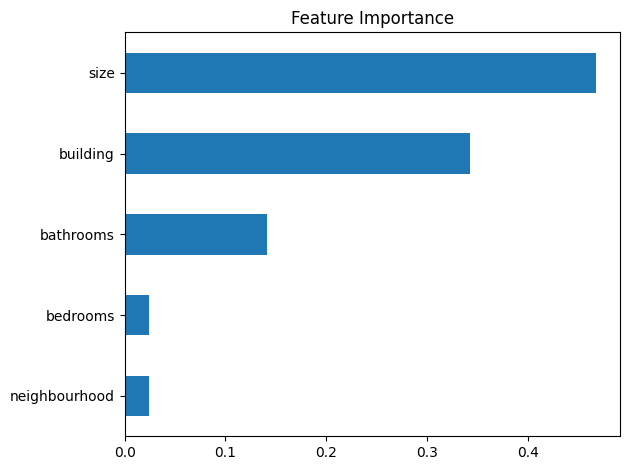

In [ ]:
# Step 4: Feature Importance with Random Forest
from sklearn.ensemble import RandomForestRegressor

X = df.drop('price', axis=1)
y = df['price']

rf_model = RandomForestRegressor()
rf_model.fit(X, y)

importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', title='Feature Importance')
plt.tight_layout()
plt.show()


#Summary for 1a:
size is the most important predictor.

bedrooms, bathrooms, and categorical variables (neighborhood, building) also influence price.

There is clear multi-variable dependence, suitable for regression.



## **1b. Build the Price Prediction Model**

 Objective:
Use property features to predict the listing price.



In [ ]:
#  Step 1: Prepare Data
from sklearn.model_selection import train_test_split

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
#  Step 2: Linear Regression Model
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)



In [ ]:
#  Step 3: Random Forest Model
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)



###Model Input/Output
Input:  [size, bedrooms, bathrooms, neighborhood, building]


Output: Predicted price

## **1c. Evaluate the Quality of the Results**

Objective:
Measure how good the predictions are.

In [ ]:
# Evaluation Metrics
from sklearn.metrics import mean_squared_error, r2_score

# Linear Regression
print("Linear Regression R²:", r2_score(y_test, y_pred_lr))
print("Linear Regression RMSE:", mean_squared_error(y_test, y_pred_lr) ** 0.5)  # Calculate RMSE by taking the square root of MSE

# Random Forest
print("Random Forest R²:", r2_score(y_test, y_pred_rf))
print("Random Forest RMSE:", mean_squared_error(y_test, y_pred_rf) ** 0.5)  # Calculate RMSE by taking the square root of MSE

Linear Regression R²: 0.0006459357824074585
Linear Regression RMSE: 5140956.292669268
Random Forest R²: -0.08685372297834326
Random Forest RMSE: 5361295.793410509


#Explanation:
R² Score shows how much variation in price is explained by the model.

RMSE tells the average error in currency units.

## **1d. Shortcomings & Extensions**

###**Shortcomings**

Limited features: Missing property age, floor, amenities, etc.

Basic encoding: Label Encoding may mislead model logic.

No cross-validation: Risk of overfitting on one train-test split.

Linear assumptions: Linear Regression can't capture complex patterns.

No market/trend data: Ignores seasonality and economic factors.



###**Extensions**

Add features like price_per_sqft, age, floor level.

Use One-Hot or Target Encoding for categories.

Try advanced models like XGBoost, LightGBM.

Apply K-Fold Cross Validation for stability.

Integrate external APIs for real estate trends.

Use SHAP to explain predictions.

#**Question 2: Property Price Valuation Tool**


##**2a. Build a Property Price Valuation Tool**

##Objective:

Build a program that determines whether a property is Underpriced, Fairly Priced, or Overpriced using the actual and predicted price.

In [ ]:
# Step 1: Define Valuation Logic

def classify_valuation(actual_price, predicted_price, threshold=0.10):
    """
    Classify the valuation based on the percentage difference.
    """
    diff_ratio = (actual_price - predicted_price) / predicted_price

    if diff_ratio < -threshold:
        return "Underpriced"
    elif diff_ratio > threshold:
        return "Overpriced"
    else:
        return "Fairly Priced"



In [ ]:
# Step 2: Example Usage

# Sample property features [size, bedrooms, bathrooms, neighborhood_encoded, building_encoded]
sample_input = [[1200, 2, 2, 3, 50]]
actual_price = 950000

# Predict price using trained model
predicted_price = rf.predict(sample_input)[0]

# Classify
valuation = classify_valuation(actual_price, predicted_price)
print(f"Predicted Price: {predicted_price}")
print(f"Valuation: {valuation}")


Predicted Price: 137900.0
Valuation: Overpriced


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


##**2b. Evaluate the Valuation Tool**

Since we don’t have true valuation labels, we evaluate indirectly:


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted 

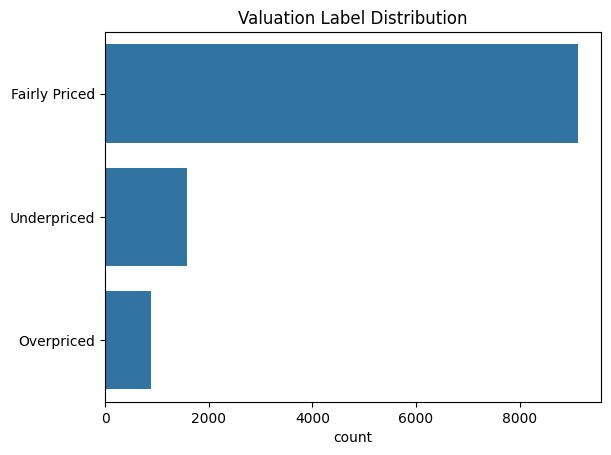

In [ ]:
# Evaluation Approaches:
 ## Distribution Check:
labels = []
for i in range(len(X_test)):
    pred = rf.predict([X_test.iloc[i]])[0]
    actual = y_test.iloc[i]
    labels.append(classify_valuation(actual, pred))

import seaborn as sns
sns.countplot(labels)
plt.title("Valuation Label Distribution")
plt.show()


##**2c. Shortcomings & Extensions**

###**Shortcomings:**

No real label of what’s “fairly priced”.

A single threshold may not fit all areas or property types.

Can misclassify in high-variance neighborhoods.


###**Extensions:**

Use dynamic thresholding based on neighborhood volatility.

Include time-sensitive pricing (seasonal price trends).

Use SHAP values to explain why a property is over or underpriced.

Combine with market data APIs to benchmark price.

#**Question 3: Explain the Predicted Price**

##Objective:

Help users understand why a property’s predicted price is what it is, and how to validate it.

###To ensure that the property price predictions are trustworthy and actionable, a robust validation and explanation framework is essential. Here’s a structured approach:

###**A. Validation Plan**

**Holdout Validation:** Split the dataset into training and test sets. Evaluate the model’s accuracy on unseen data using metrics such as Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score. This quantifies how close predictions are to actual prices.

**Cross-Validation:** Use k-fold cross-validation to ensure the model’s performance is consistent across different data splits, reducing the risk of overfitting to a particular subset.

**Baseline Comparison:** Compare the model’s performance to simple baselines (e.g., predicting the mean or median price for a given neighborhood or property type) to demonstrate added value.

**Feature Importance Analysis:** Use model explainability tools (e.g., SHAP, LIME) to show which features most influence the predicted price. This helps users understand why the model made a specific prediction.

**Outlier and Residual Analysis:** Analyze where the model performs poorly (i.e., large prediction errors) to identify data quality issues or market anomalies.

**External Benchmarking:** If possible, compare predictions to external market data (e.g., recent sales, third-party valuation tools) to validate that the model’s outputs are reasonable in the current market context.

###**B. Additional Data Points for Enhanced Validation**

**Recent Transaction Prices:** Incorporate actual recent sale prices for similar properties to benchmark predictions.

**Market Trends:** Use time-series data on price trends in each neighborhood to adjust or validate predictions.

**Property Condition and Amenities:** If available, include data on property condition, renovations, or special amenities, as these can significantly affect price.

###**C. User-Facing Validation Metrics**

**Confidence Intervals:** Provide a range (e.g., ±10%) around the predicted price to communicate model uncertainty.

**Explainable Predictions:** For each prediction, display the top contributing features (e.g., “The price is higher due to large size and prime neighborhood”).

**Historical Performance:** Show users how accurate the model has been in the past for similar properties (e.g., “For 50 similar properties, model error was ±5%”).

###**D. Transparency and Trust**

**Model Documentation:** Clearly document model assumptions, limitations, and data sources.

**User Feedback Loop:** Allow users to flag questionable predictions, which can be reviewed and used to improve the model.

This approach ensures that predictions are both technically validated and understandable to end users, building trust in the tool and supporting informed decision-making.


#**Question 4: Deployment Architecture**



**4a. System Architecture Diagram**


###**Architecture Explanation**

This diagram outlines how the Property Price Prediction + Valuation

Tool is served to users:

###**User**

The end-user (e.g., buyer, seller, agent) interacts with the system through a web application.

They enter property details like size, number of bedrooms, bathrooms, location, and listing price.

###**Web UI (React or HTML Form)**

The frontend collects user input.

It sends this input to the backend through an API request (typically in JSON format).

###**FastAPI / Flask Backend**

Acts as a bridge between the frontend and the machine learning model.

Receives property details from the frontend.

Calls the trained model to generate a predicted price.

Passes the result to the valuation logic.

###**Prediction Model (e.g., Random Forest)**

The model uses trained data to predict the property's fair market price.

This prediction is then used to compare with the actual user-provided price.

###**Valuation Logic**

Compares the predicted price vs. the user’s listing price.

Applies rules (e.g., ±10% threshold) to classify:

Underpriced

Fairly Priced

Overpriced

###**Output to User**

The system sends back:

Predicted price

Valuation status

(Optional: explanation or SHAP plot)

The result is displayed in the UI for the user.

#**Summary:**

This architecture ensures that:

Users get fast and accurate predictions.

Business logic is modular (prediction + valuation).

It’s easy to scale, secure, and explain results back to users.

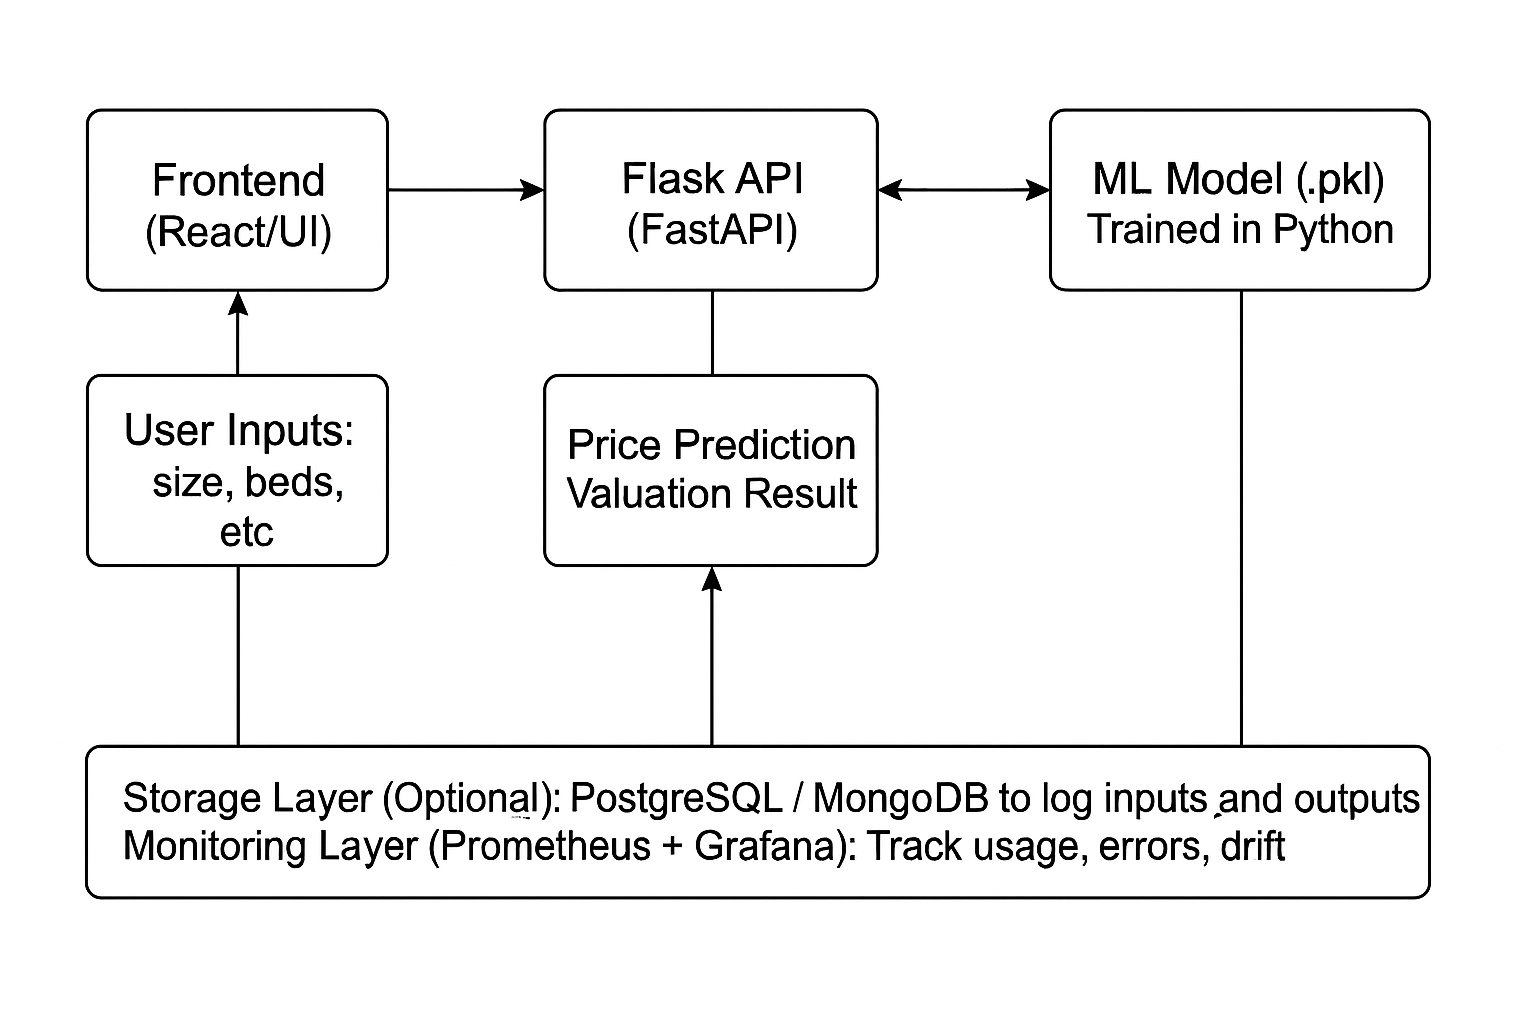

[[[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [254 255 255]
  [255 255 254]]

 ...

 [[255 255 255]
  [255 255 254]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[254 255 255]
  [255 255 254]
  [255 255 255]
  ...
  [255 254 255]
  [255 255 255]
  [255 255 255]]]


In [1]:
import cv2
from google.colab.patches import cv2_imshow

image = cv2.imread('architecture.png')

if image is None:
    print("Error: Image not found or unable to load.")
else:
    cv2_imshow(image)
    #cv2.waitKey(0)      # Wait for any key press - Not needed in Colab
    #cv2.destroyAllWindows() - Not needed in Colab

print(image)

##**4B. Scalability**

Stateless Microservices: Deploy prediction and valuation services as stateless microservices, allowing horizontal scaling (add more instances as traffic increases).

Load Balancer: Distributes incoming requests across multiple service instances.

Cloud Deployment: Use cloud infrastructure (AWS, Azure, GCP) with auto-scaling groups and managed databases.

Containerization: Package services in containers (Docker) for portability and rapid scaling.

##**4C. Key Performance Indicators (KPIs**)

Prediction Accuracy: Track MAE, RMSE, and percentage of predictions within a certain error margin.

System Uptime: Percentage of time the service is available.

Response Time: Average time to return a prediction/valuation.

User Engagement: Number of queries, repeat users, feedback received.

Model Drift: Monitor if model accuracy degrades over time due to market changes.

##**4D. Monitoring Tool Performance**

Automated Monitoring: Use tools like Prometheus, Grafana, or cloud-native monitoring to track API latency, error rates, and system health.

Model Monitoring: Regularly evaluate prediction errors and retrain the model if performance drops.

User Feedback: Collect and analyze user feedback on prediction quality.

Alerting: Set up alerts for anomalies (e.g., sudden spike in errors, slow responses, or significant prediction deviations).